In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

# The model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()
# no null value in columns

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Checking outliers before modelling

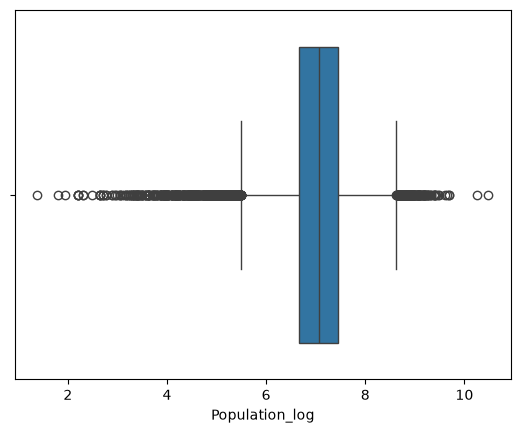

In [4]:
# columns_to_check = ['MedInc', 'HouseAge', 'AveRooms','AveBedrms','Population','AveOccup']
# columns_to_check = ['Population']

# Plotting them side-by-side
# sns.boxplot(data=df[columns_to_check])
# plt.show()

df['Population_log'] = np.log1p(df['Population'])
sns.boxplot(x=df['Population_log'])
plt.show()

In [5]:
print(df['Population'].describe())

count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: Population, dtype: float64


In [6]:
# Dropping very small population households
df = df[df['Population'] >= 50]

In [7]:
print(df['AveOccup'].describe())

count    20536.000000
mean         3.071548
std         10.411438
min          0.970588
25%          2.432108
50%          2.819632
75%          3.281612
max       1243.333333
Name: AveOccup, dtype: float64


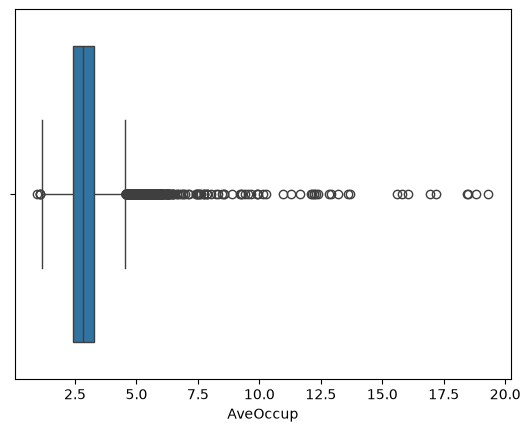

In [10]:
# check occupation per house by plot
sns.boxplot(x=df['AveOccup'])
plt.show()

In [9]:
# print(df.nsmallest(10, 'Population'))
# df.nlargest(10,'AveOccup')

# Dropping Occupation number > 20 per house rows #10 rows only
df = df[df['AveOccup'] <= 20]

## Checking HouseAge column for odd outliers

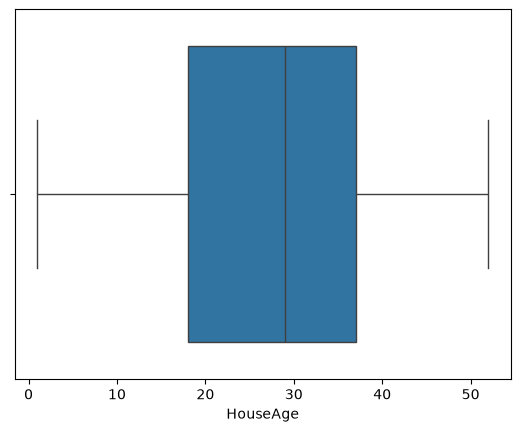

In [11]:
sns.boxplot(x=df['HouseAge'])
plt.show()
# looks pretty normal

In [12]:
df[['MedInc','AveRooms','AveBedrms','MedHouseVal']].describe()

,MedInc,AveRooms,AveBedrms,MedHouseVal
count,20526.000000,20526.000000,20526.000000,20526.000000
mean,3.870436,5.402379,1.090482,2.068809
std,1.889870,2.012817,0.344874,1.152683
min,0.499900,0.888889,0.444444,0.149990
25%,2.566325,4.441055,1.006332,1.198250
50%,3.536000,5.227887,1.048771,1.798000
75%,4.742600,6.048469,1.099081,2.647000
max,15.000100,62.422222,14.111111,5.000010


In [13]:
# print((df['MedHouseVal'] >= 5).sum())
df['MedHouseVal'].describe()

count    20526.000000
mean         2.068809
std          1.152683
min          0.149990
25%          1.198250
50%          1.798000
75%          2.647000
max          5.000010
Name: MedHouseVal, dtype: float64

In [18]:
# filter out rooms > 20
df = df[df['AveRooms'] <= 20]

In [19]:
# nearly a thousand rows for 500k and 1 dollar mark. suspicious , not a real value
df = df[df['MedHouseVal'] != 5.00001]

# Data is all Clean. Modelling and predicting phase

In [36]:
# features
X = df[['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup']]
# target
y = df['MedHouseVal']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,shuffle=True,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

r2_score(y_test,y_pred)

0.5564613780868908

### Lets add coordinates if it will improve the result

In [38]:
X2 = df[['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, shuffle=True, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

r2_score(y2_test, y2_pred)

0.6302897045094471

In [39]:
coefs = pd.Series(model.coef_, index=X.columns)
print(coefs.sort_values(ascending=False))

AveBedrms     1.157002
MedInc        0.575229
HouseAge      0.015514
Population    0.000050
AveOccup     -0.211954
AveRooms     -0.274670
dtype: float64


In [40]:
print(df[['AveRooms','AveBedrms']].corr())

           AveRooms  AveBedrms
AveRooms   1.000000   0.519119
AveBedrms  0.519119   1.000000


In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

      feature        VIF
0      MedInc  12.095440
1    HouseAge   5.813475
2    AveRooms  47.529435
3   AveBedrms  38.062902
4  Population   2.890564
5    AveOccup  10.842061


In [42]:
df['BedrmRatio'] = df['AveBedrms'] / df['AveRooms']
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Population_log,BedrmRatio
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,5.777652,0.146591
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,7.784057,0.155797
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,6.208590,0.129516
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,6.326149,0.184458
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,6.338594,0.172096


In [43]:
X3 = df[['MedInc','HouseAge','BedrmRatio','Population','AveOccup','Latitude','Longitude']]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, shuffle=True, random_state=42)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)

r2_score(y3_test, y3_pred)

0.637004113579567

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = df[['MedInc','HouseAge','AveRooms','BedrmRatio','Population','AveOccup']]
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

      feature        VIF
0      MedInc   9.832099
1    HouseAge   6.485645
2    AveRooms  16.188629
3  BedrmRatio  10.789038
4  Population   2.976138
5    AveOccup  12.122519
